# [LAB-10] 11. 이원분산분석 (Twoway ANOVA)

두 개의 명목형 요인(예: 성별 x 교육방법)이 연속형 종속변수의 평균에 어떤 영향을 미치는지,
그리고 두 요인 간 상호작용 효과가 존재하는지를 검정하는 통계 방법.  
분석을 수행하기 전에는 일원분산분석과 동일하게 정규성과 등분산성 등의 기본 가정이 충족되
어야 한다.    
이원 분산분석의 주요 목적은 상호작용 효과의 존재 여부를 파악하는 데 있으므로, 수준이 3개
이상인 요인의 주효과가 유의할 때 해당 요인에 대해서만 사후검정을 수행한다.   

In [1]:
from hossam import load_data
from pandas import melt, DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt

# 가정 확인을 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene

# 분산분석을 위한 라이브러리
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from pingouin import anova
from pingouin import welch_anova

# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_tests, pairwise_gameshowell

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)  # 폰트의 속성을 읽어옴
fname = fprop.get_name()  # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams["font.family"] = fname
plt.rcParams["font.size"] = 10
plt.rcParams["axes.unicode_minus"] = False

In [3]:
origin = load_data("sunlight_watering_growth")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/sunlight_watering_growth.xlsx
[desc] 식물의 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록한 데이터 (출처: 방송통신대학교 통계학개론)

field    description
-------  ----------------------------------------------------------------
water    각 식물에 물을 주는 빈도 (매일:`daily`, 매주: `weekly`)
sun      각 식물이 받은 햇빛 노출량 (낮음:`low`, 중간:`med`, 높음:`high`)
height   2개월 후 각 식물의 높이 (인치)


===== 데이터 크기 확인 =====
데이터셋 크기: (120, 3)
열 개수: 3
행 개수: 120

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   water   120 non-null    object 
 1   sun     120 non-null    object 
 2   height  120 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.9+ KB
None


,water,sun,height
0,daily,low,4.9
1,daily,low,7.9
2,daily,low,3.9
3,daily,low,5.1
4,daily,low,5.2


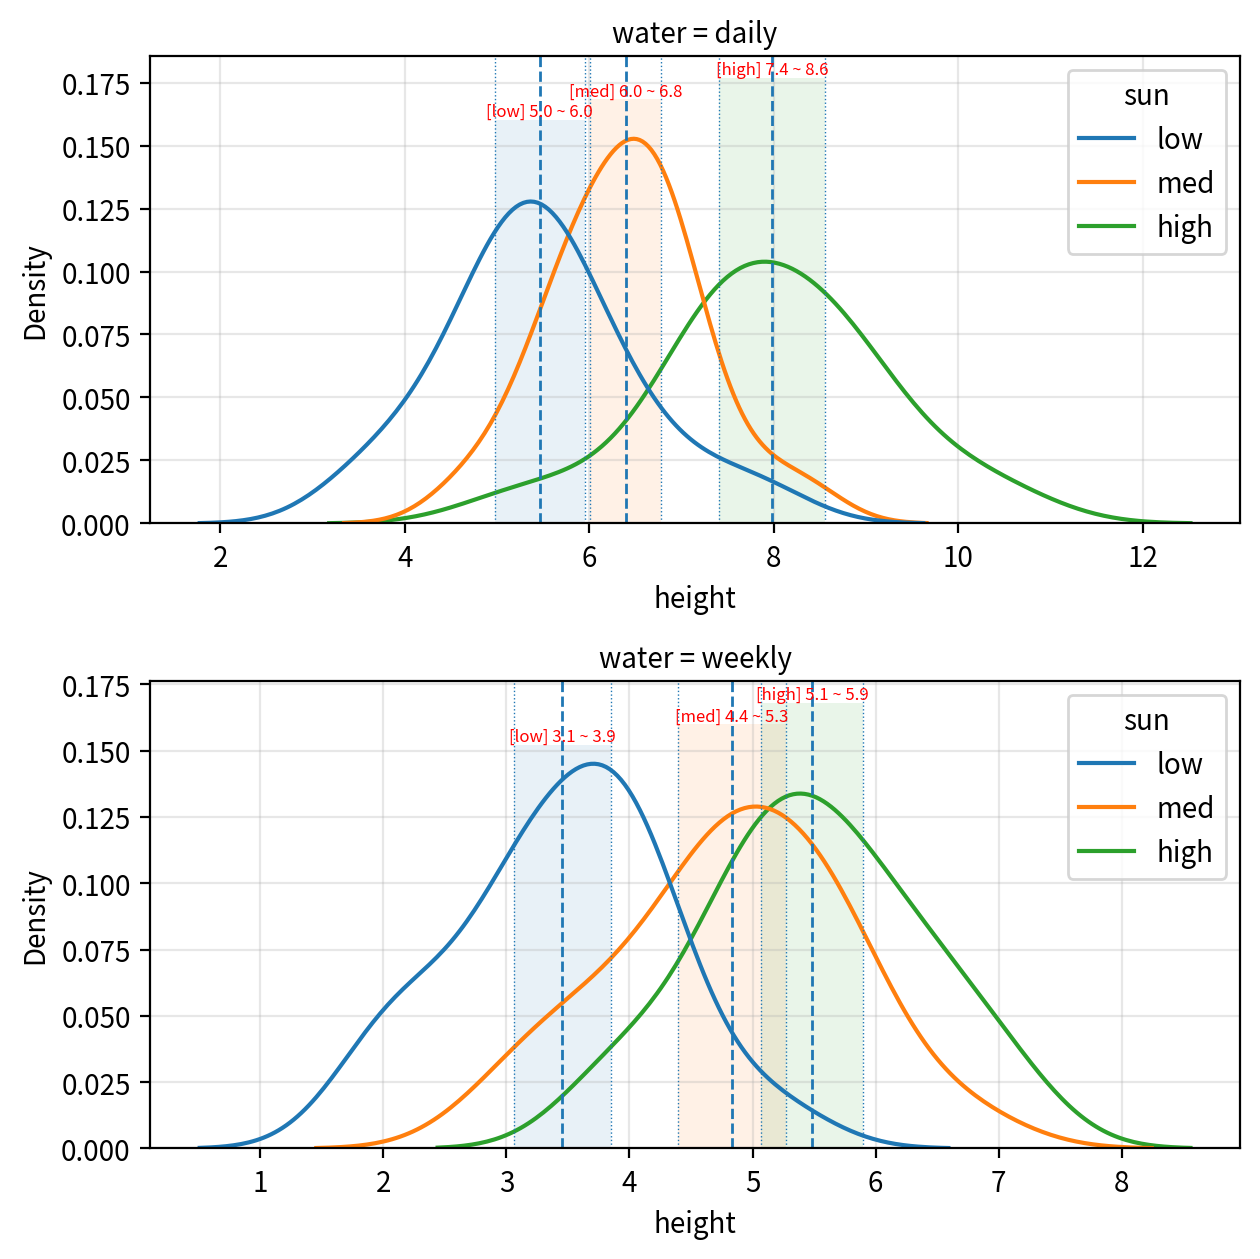

In [4]:
field = "height"
group_field = "water"
hue_field = "sun"

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count  # 그래프 행 수
cols = 1  # 그래프 열 수
width_px = 1280 * cols  # 그래프 가로 크기
height_px = 640 * rows  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)

# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    # 그룹별 데이터 필터링
    temp = data[data[group_field] == v]

    # KDE Plot
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title("{0} = {1}".format(group_field, v), fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        # 신뢰구간
        max_val = temp_sub[field].max()  # 최대값 (필요시 사용)
        clevel = 0.95  # 신뢰수준
        dof = len(temp_sub[field]) - 1  # 자유도
        sp_mean = temp_sub[field].mean()  # 표본평균
        sp_std = temp_sub[field].std(ddof=1)  # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))  # 표본표준오차

        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        # 신뢰구간 경계선
        ax[i].axvline(cmin, linestyle=":", linewidth=0.5)
        ax[i].axvline(cmax, linestyle=":", linewidth=0.5)

        # 평균 및 신뢰구간 영역 표시
        ymin, ymax = ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle="--", linewidth=1)

        # 텍스트 그리기
        ax[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"},
        )

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

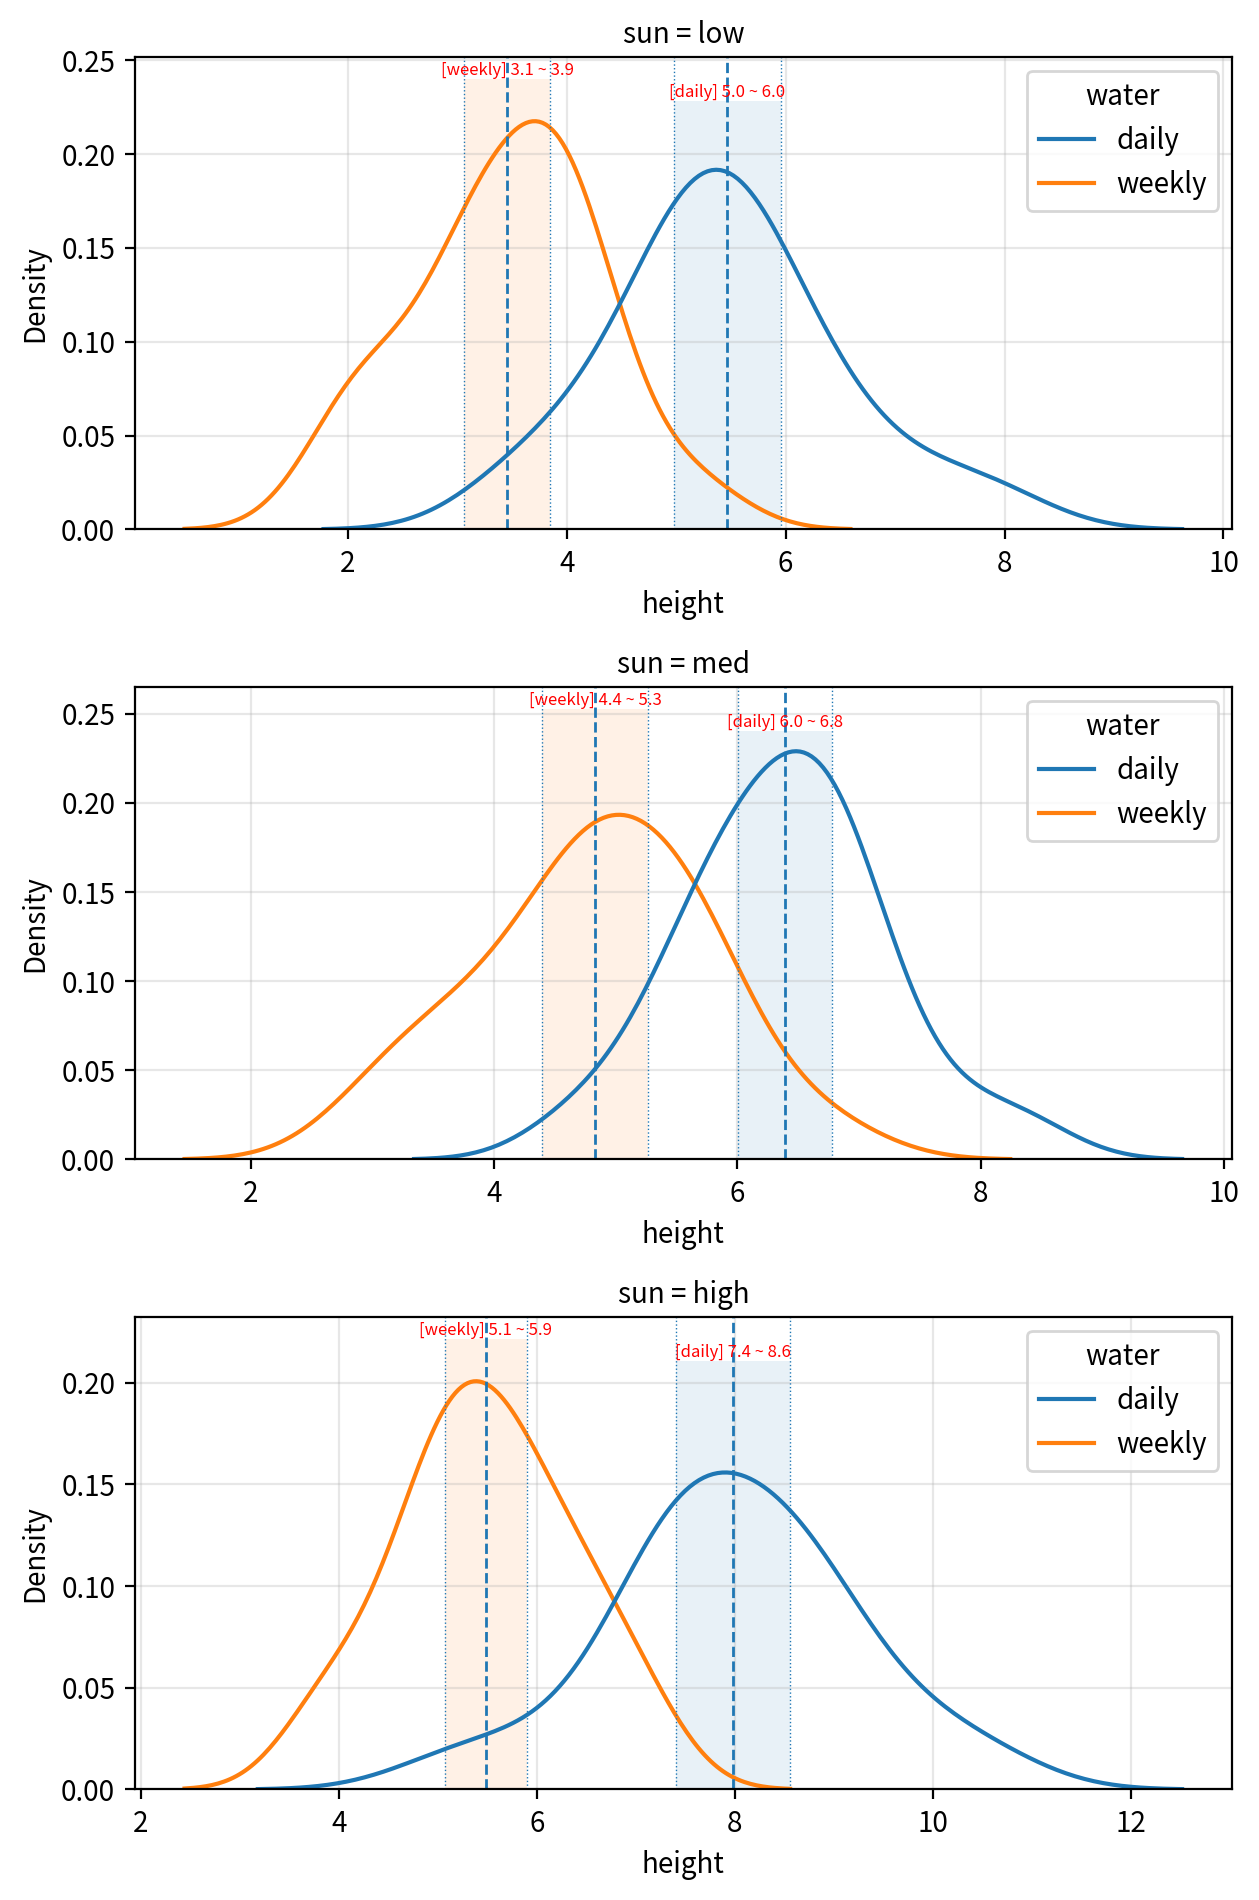

In [5]:
field = "height"
group_field = "sun"
hue_field = "water"

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]].dropna()
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count  # 그래프 행 수
cols = 1  # 그래프 열 수
width_px = 1280 * cols  # 그래프 가로 크기
height_px = 640 * rows  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)

# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# rows가 1이면 ax가 단일 객체라서 리스트로 감싸줌
axes = ax if rows > 1 else [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    # 그룹별 데이터 필터링
    temp = data[data[group_field] == v]

    # KDE Plot
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=axes[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title("{0} = {1}".format(group_field, v), fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]
        if len(temp_sub) == 0:
            continue  # 해당 조합 데이터 없으면 스킵

        # 신뢰구간 계산
        max_val = temp_sub[field].max()  # 최대값 (필요하면 사용)
        clevel = 0.95  # 신뢰수준
        dof = len(temp_sub[field]) - 1  # 자유도
        sp_mean = temp_sub[field].mean()  # 표본평균
        sp_std = temp_sub[field].std(ddof=1)  # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))  # 표본표준오차

        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        # 신뢰구간 경계선
        axes[i].axvline(cmin, linestyle=":", linewidth=0.5)
        axes[i].axvline(cmax, linestyle=":", linewidth=0.5)

        # 평균 및 신뢰구간 영역 표시
        ymin, ymax = axes[i].get_ylim()
        axes[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        axes[i].axvline(sp_mean, linestyle="--", linewidth=1)

        # 텍스트 그리기
        axes[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"},
        )

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [7]:
data = origin.copy()

xname = ["water", "sun"]  # 두 개의 요인(범주형 변수)
yname = "height"  # 종속 변수

u1 = data[xname[0]].unique()
u2 = data[xname[1]].unique()

equal_var_fields = []
normal_dist = True
report = []

for i in u1:
    for j in u2:
        # 두 요인의 조합별로 데이터 필터링
        filtered_data = data[(data[xname[0]] == i) & (data[xname[1]] == j)][
            yname
        ].dropna()

        # 데이터가 없으면 스킵
        if len(filtered_data) == 0:
            continue

        equal_var_fields.append(filtered_data)

        # 정규성 검정
        s, p = normaltest(filtered_data)
        normalize = p > 0.05

        report.append(
            {
                "field": "{0}={1}, {2}={3}".format(xname[0], i, xname[1], j),
                "statistic": s,
                "p-value": p,
                "result": normalize,
            }
        )

        normal_dist = normal_dist and normalize

# 전체 그룹들이 모두 정규성을 만족하는지에 따라 등분산 검정 선택
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*equal_var_fields)
else:
    n = "Levene"
    s, p = levene(*equal_var_fields)

equal_var = p > 0.05  # 필요하면 따로 사용

report.append({"field": n, "statistic": s, "p-value": p, "result": p > 0.05})

report_df = DataFrame(report).set_index("field")
report_df

,statistic,p-value,result
field,,,
"water=daily, sun=low",1.461514,0.481544,True
"water=daily, sun=med",0.866582,0.648372,True
"water=daily, sun=high",0.801917,0.669678,True
"water=weekly, sun=low",0.073958,0.963697,True
"water=weekly, sun=med",0.160764,0.922764,True
"water=weekly, sun=high",0.052520,0.974082,True
Bartlett,4.488400,0.481437,True


In [8]:
xname = ["water", "sun"]
yname = "height"
pg_anova = anova(data=origin, dv=yname, between=xname)
pg_anova

,Source,SS,DF,MS,F,p-unc,np2
0,water,122.816333,1,122.816333,130.528994,1.301312e-20,0.533798
1,sun,103.292167,2,51.646083,54.889371,2.013276e-17,0.490568
2,water * sun,4.327167,2,2.163583,2.299453,1.049489e-01,0.038777
3,Residual,107.264000,114,0.940912,NaN,NaN,NaN


In [12]:
for idx in pg_anova.index:
    row = pg_anova.iloc[idx]
    source = row["Source"]
    p_val = row["p-unc"]

    if p_val <= 0.05:
        print(f"→ {source} 효과는 유의함. (대립가설 채택: p ≤ 0.05)")
    else:
        print(f"→ {source} 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)")

→ water 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ sun 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ water * sun 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)
→ Residual 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)


In [13]:
xname = ["water", "sun"]
yname = "height"

data = origin[xname + [yname]]

levels = {}  # 빈 딕셔너리 만들기
# 예: {'water': 2, 'sun': 3} 이런 식 결과
for factor in xname:  # 요인을 하나씩 꺼냄
    level_count = data[factor].nunique()  # 요인의 수준 수 계산
    levels[factor] = level_count  # 딕셔너리에 저장

pvals = {}  # 빈 딕셔너리 만들기
# 예: {'water': 1.30e-20, 'sun': 2.01e-17, 'water * sun': 0.105}
for index, row in pg_anova.iterrows():  # 행을 하나씩 꺼냄
    source_name = row["Source"]  # 요인 이름
    p_value = row["p-unc"]  # 각 요인의 p-value
    pvals[source_name] = p_value  # 딕셔너리에 저장

# 주효과 사후검정
for factor in xname:
    print(f"\n[{factor}]")

    # 수준이 2개면 사후검정 필요 없음
    if levels[factor] == 2:
        print(f"- {levels[factor]}수준 요인이므로 사후검정이 필요 없습니다.")
        continue

    p_val = pvals.get(factor, None)
    if p_val is None:
        print("- ANOVA 결과에서 해당 요인을 찾을 수 없습니다.")
        continue

    if p_val > 0.05:
        print(f"- 주효과 유의하지 않음 (p={p_val:.3g}) → 사후검정 수행 안 함")
        continue

    print(f"- 주효과 유의 (p={p_val:.3g}) → 사후검정 수행")

    if equal_var:
        print(" · Tukey HSD 사용 (등분산 충족)")
        hoc_df = pairwise_tukey(data=data, dv=yname, between=factor)
    else:
        print(" · Games–Howell 사용 (등분산 불충족)")
        hoc_df = pairwise_gameshowell(data=data, dv=yname, between=factor)

    display(hoc_df)

# 상호작용 자동 처리
interaction_names = [src for src in pvals.keys() if "*" in src]

for inter in interaction_names:
    p_val = pvals[inter]
    print(f"\n[{inter}] 상호작용 효과")

    if p_val <= 0.05:
        print(f"- 상호작용 유의 (p={p_val:.3g}) → 단순주효과 분석 필요")
    else:
        print(f"- 상호작용 유의하지 않음 (p={p_val:.3g}) → 단순주효과 분석 필요 없음")


[water]
- 2수준 요인이므로 사후검정이 필요 없습니다.

[sun]
- 주효과 유의 (p=2.01e-17) → 사후검정 수행
 · Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,high,low,6.7325,4.4600,2.2725,0.316503,7.180027,2.079096e-10,1.480100
1,high,med,6.7325,5.6125,1.1200,0.316503,3.538671,1.663237e-03,0.775153
2,low,med,4.4600,5.6125,-1.1525,0.316503,-3.641356,1.172021e-03,-0.888359



[water * sun] 상호작용 효과
- 상호작용 유의하지 않음 (p=0.105) → 단순주효과 분석 필요 없음


📝 1. 분석 목적

본 분석은 {DV}에 대해 {요인들}이 어떠한 영향을 미치는지를 검증하기 위해 분산분석(ANOVA)
을 수행하였다.

📝 2. 분산분석 주요 결과
2-1. 요인별 유의성 판단
- {요인1}: F = {F값}, p = {p값}, ηp² = {효과크기} → {유의성 판단}
- {요인2}: F = {F값}, p = {p값}, ηp² = {효과크기} → {유의성 판단}
- {상호작용}: F = {F값}, p = {p값}, ηp² = {효과크기} → {유의성 판단}
(**요약:**) {핵심 요약문 1–2문장}

📝 3. 기술통계 및 집단별 평균 비교
- {요인1} 수준별 평균: …
- {요인2} 수준별 평균: …
- 상호작용 조합 평균(해당 시): …
(**요약 해석:**) {패턴 설명}

📝 4. 사후검정(Post-hoc) 결과
- {요인1}: {수준 수}수준 → {사후검정 여부 및 이유}
- {요인2}: {사후검정 결과 요약}
- 상호작용(simple effects): {필요 여부}
(**요약 해석:**) {사후검정으로 확인된 구체적 차이}

📝 5. 최종 결론 요약
- • {핵심 인사이트 1}
- • {핵심 인사이트 2}
- • {핵심 인사이트 3}
- • {모형의 의미 있는 해석}
(**최종 한 문장 결론:**) {DV}는 {주요 요인}의 영향을 크게 받으며, {상호작용 여부}가 확인되었다.